In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [78]:
data = pd.read_json("../results/yp.json")

# Filter outliars
# data = data[data["time"] < 1.0]

print(data["device_count"].value_counts())

data

device_count
1    1000
2    1000
4    1000
Name: count, dtype: int64


,timestamp,time,device_count,max_seq_len,prompt_length,max_tokens,yield_probability,total_generated_tokens,yield_count
0,2025-10-07 13:00:13.293729544,0.730066,1,8192,8229,1,0.458010,1,18
1,2025-10-07 13:00:13.849583387,0.554715,1,8192,7284,1,0.836980,1,18
2,2025-10-07 13:00:13.949506760,0.098852,1,8192,2246,1,0.703194,1,18
3,2025-10-07 13:00:14.012657881,0.062073,1,8192,1346,1,0.575244,1,18
4,2025-10-07 13:00:14.206739664,0.192708,1,8192,4049,1,0.288235,1,18
...,...,...,...,...,...,...,...,...,...
2995,2025-10-07 13:31:33.636642218,0.796979,4,8192,8734,1,0.432595,1,72
2996,2025-10-07 13:31:35.505304337,0.493030,4,8192,6859,1,0.160012,1,72
2997,2025-10-07 13:31:35.747287750,0.083982,4,8192,1718,1,0.578448,1,72
2998,2025-10-07 13:31:36.773352385,0.275286,4,8192,5009,1,0.922299,1,72


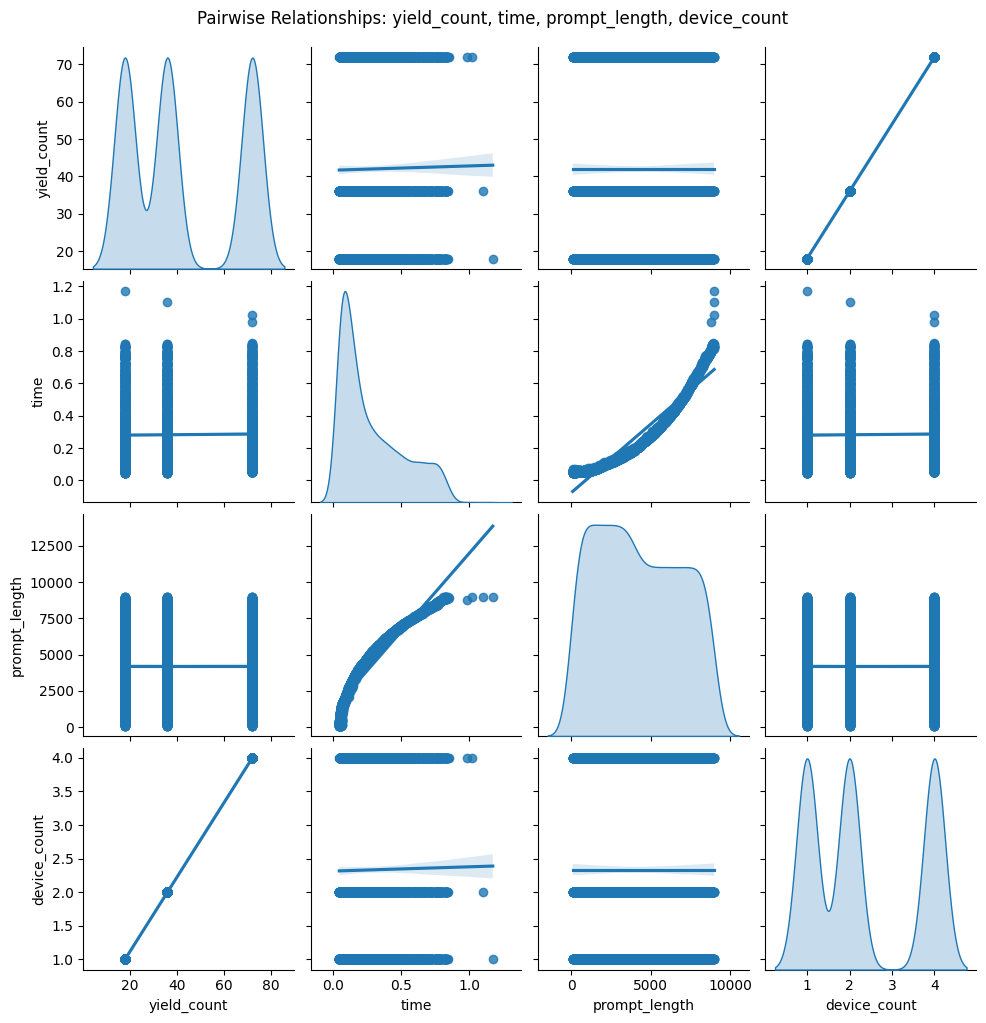

Correlation matrix:
                 yield_count      time  prompt_length  device_count
yield_count    1.000000e+00  0.011766   1.015402e-15  1.000000e+00
time           1.176649e-02  1.000000   9.576608e-01  1.176649e-02
prompt_length  1.015402e-15  0.957661   1.000000e+00  1.023220e-15
device_count   1.000000e+00  0.011766   1.023220e-15  1.000000e+00


In [79]:
import seaborn as sns

# Select relevant columns
corr_data = data[["yield_count", "time", "prompt_length", "device_count"]]

# Pairplot to visualize relationships
sns.pairplot(corr_data, kind="reg", diag_kind="kde")
plt.suptitle("Pairwise Relationships: yield_count, time, prompt_length, device_count", y=1.02)
plt.show()

# Display correlation matrix
corr_matrix = corr_data.corr()
print("Correlation matrix:\n", corr_matrix)

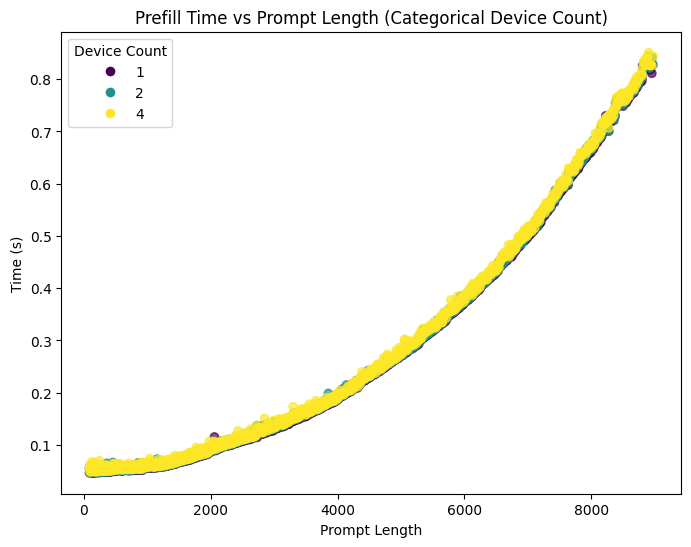

In [81]:
# Get unique device counts and assign categorical colors
filtered_data = data[data["time"] < 0.9]

unique_devices = np.sort(filtered_data["device_count"].unique())
palette = plt.get_cmap("viridis")
color_map = {dev: palette(i * 128) for i, dev in enumerate(unique_devices)}
colors = filtered_data["device_count"].map(color_map)

plt.figure(figsize=(8, 6))
sc = plt.scatter(filtered_data["prompt_length"], filtered_data["time"], c=colors, alpha=0.7)
plt.xlabel("Prompt Length")
plt.ylabel("Time (s)")
plt.title("Prefill Time vs Prompt Length (Categorical Device Count)")

# Create a legend for device_count
handles = [plt.Line2D([0], [0], marker='o', color='w', label=str(dev),
                      markerfacecolor=color_map[dev], markersize=8)
           for i, dev in enumerate(unique_devices)]
plt.legend(handles=handles, title="Device Count")
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm

scaler = MinMaxScaler()
df = data.copy()
df["prompt_length_sq"] = df["prompt_length"]**2
X_raw = df[["prompt_length", "prompt_length_sq", "yield_count", "device_count", "time"]]
X_norm = scaler.fit_transform(X_raw)

X1 = pd.DataFrame(X_norm, columns=X_raw.columns)[["prompt_length"]]
X2 = pd.DataFrame(X_norm, columns=X_raw.columns)[["prompt_length", "prompt_length_sq"]]
X3 = pd.DataFrame(X_norm, columns=X_raw.columns)[["prompt_length", "prompt_length_sq", "yield_count"]]
X4 = pd.DataFrame(X_norm, columns=X_raw.columns)[["prompt_length", "prompt_length_sq", "yield_count", "device_count"]]
y = X_raw["time"]

X1 = sm.add_constant(X1)
X2 = sm.add_constant(X2)
X3 = sm.add_constant(X3)
X4 = sm.add_constant(X4)

model1 = sm.OLS(y, X1).fit()
model2 = sm.OLS(y, X2).fit()
model3 = sm.OLS(y, X3).fit()
model4 = sm.OLS(y, X4).fit()

print(model4.summary())
print("F-test p-value for adding device_count:", model4.compare_f_test(model3)[1])
print("F-test p-value for adding yield_count:", model3.compare_f_test(model2)[1])
print("F-test p-value for adding prompt_length_sq:", model2.compare_f_test(model1)[1])

print("R-squared values:")
print("Model 1 (prompt_length):", model1.rsquared)
print("Model 2 (prompt_length + prompt_length_sq):", model2.rsquared)
print("Model 3 (prompt_length + prompt_length_sq + yield_count):", model3.rsquared)
print("Model 4 (prompt_length + prompt_length_sq + yield_count + device_count):", model4.rsquared)

                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 3.472e+05
Date:                Fri, 17 Oct 2025   Prob (F-statistic):               0.00
Time:                        18:07:19   Log-Likelihood:                 8926.9
No. Observations:                3000   AIC:                        -1.785e+04
Df Residuals:                    2996   BIC:                        -1.782e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0585      0.001  

/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:2284: RuntimeWarning: divide by zero encountered in scalar divide
  f_value = (ssr_restr - ssr_full) / df_diff / ssr_full * df_full


                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 3.472e+05
Date:                Fri, 17 Oct 2025   Prob (F-statistic):               0.00
Time:                        18:07:19   Log-Likelihood:                 8926.9
No. Observations:                3000   AIC:                        -1.785e+04
Df Residuals:                    2996   BIC:                        -1.782e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0585      0.001  

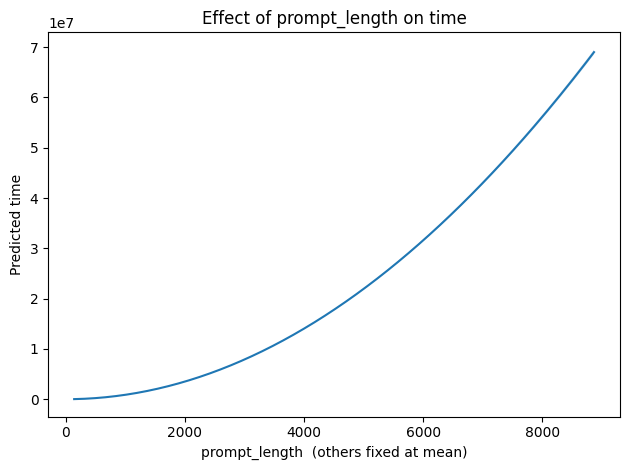

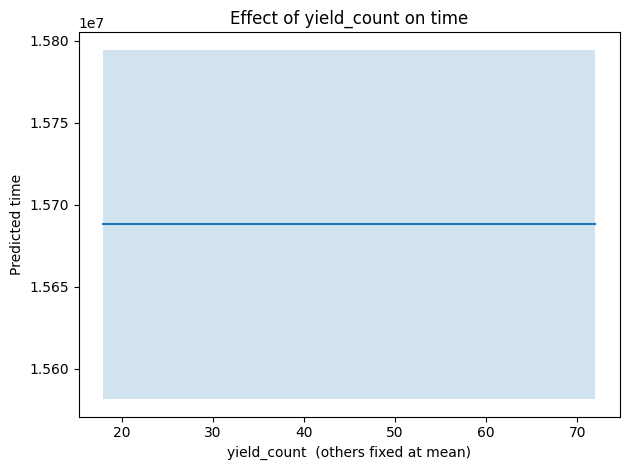

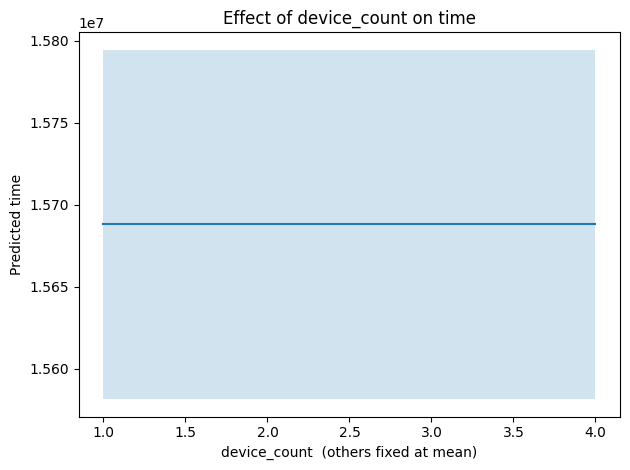

In [ ]:
# pip install pandas numpy statsmodels matplotlib
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Assume df already has: time, prompt_length, yield_count
df = data.copy()

# ------------------------------------------------------------
# 1) Add quadratic terms
# ------------------------------------------------------------
df["prompt_length_sq"] = df["prompt_length"]**2

# ------------------------------------------------------------
# 2) Fit quadratic OLS model
# ------------------------------------------------------------
scaler = MinMaxScaler()
X_raw = df[["prompt_length", "yield_count", "prompt_length_sq", "device_count"]]
X_norm = scaler.fit_transform(X_raw)

X = pd.DataFrame(X_norm, columns=X_raw.columns)
X = sm.add_constant(X)
y = df["time"]

quad_model = sm.OLS(y, X).fit()
print(quad_model.summary())

# ------------------------------------------------------------
# 3) Effect plot for prompt_length (quadratic)
# ------------------------------------------------------------
def quadratic_effect_plot(var_name, hold_vars, n=200):
    hold_vals = {k: df[k].mean() for k in hold_vars}
    vmin, vmax = np.percentile(df[var_name], [1, 99])
    grid = np.linspace(vmin, vmax, n)

    design = pd.DataFrame({
        "const": 1.0,
        "prompt_length": grid if var_name == "prompt_length" else hold_vals["prompt_length"],
        "yield_count": grid if var_name == "yield_count" else hold_vals["yield_count"],
        "prompt_length_sq": (grid if var_name == "prompt_length" else hold_vals["prompt_length"])**2,
        "device_count": grid if var_name == "device_count" else hold_vals["device_count"],
    })

    pred_res = quad_model.get_prediction(design).summary_frame(alpha=0.05)

    plt.figure()
    plt.plot(grid, pred_res["mean"])
    plt.fill_between(grid, pred_res["mean_ci_lower"], pred_res["mean_ci_upper"], alpha=0.2)
    plt.xlabel(var_name + f"  (others fixed at mean)")
    plt.ylabel("Predicted time")
    plt.title(f"Effect of {var_name} on time")
    plt.tight_layout()
    plt.show()

quadratic_effect_plot("prompt_length", ["yield_count", "device_count"])
quadratic_effect_plot("yield_count", ["prompt_length", "device_count"])
quadratic_effect_plot("device_count", ["prompt_length", "yield_count"])


In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression

# Fit a linear regression model for sensitivity analysis
lr = LinearRegression()
lr.fit(X_raw, y)

# Permutation importance (global sensitivity)
result = permutation_importance(lr, X_raw, y, n_repeats=10, random_state=42, scoring='neg_mean_squared_error')

# Display results
importances = pd.Series(result.importances_mean, index=X_raw.columns)
importances = importances.sort_values(ascending=False)
print("Permutation Importance (Global Sensitivity):")
print(importances)

Permutation Importance (Global Sensitivity):
prompt_length_sq    1.336232e-01
prompt_length       1.754319e-03
yield_count         1.483319e-05
device_count        3.628033e-10
dtype: float64


In [ ]:
data = pd.read_json("../results/yps.json")
data

,timestamp,time,device_count,max_seq_len,prompt_length,max_tokens,yield_probability,total_generated_tokens,yield_count
0,2025-10-06 16:41:24.278948307,0.084937,1,8192,94,1,0,1,18
1,2025-10-06 16:41:24.324468136,0.044481,1,8192,94,1,0,1,18
2,2025-10-06 16:41:24.368552208,0.043094,1,8192,94,1,0,1,18
3,2025-10-06 16:41:24.412144899,0.042566,1,8192,94,1,0,1,18
4,2025-10-06 16:41:24.455515385,0.042350,1,8192,94,1,0,1,18
...,...,...,...,...,...,...,...,...,...
2395,2025-10-06 17:03:59.430732012,0.899597,4,8192,9219,1,1,1,72
2396,2025-10-06 17:04:02.886851788,0.887974,4,8192,9219,1,1,1,72
2397,2025-10-06 17:04:06.338347435,0.888995,4,8192,9219,1,1,1,72
2398,2025-10-06 17:04:09.781385899,0.884767,4,8192,9219,1,1,1,72


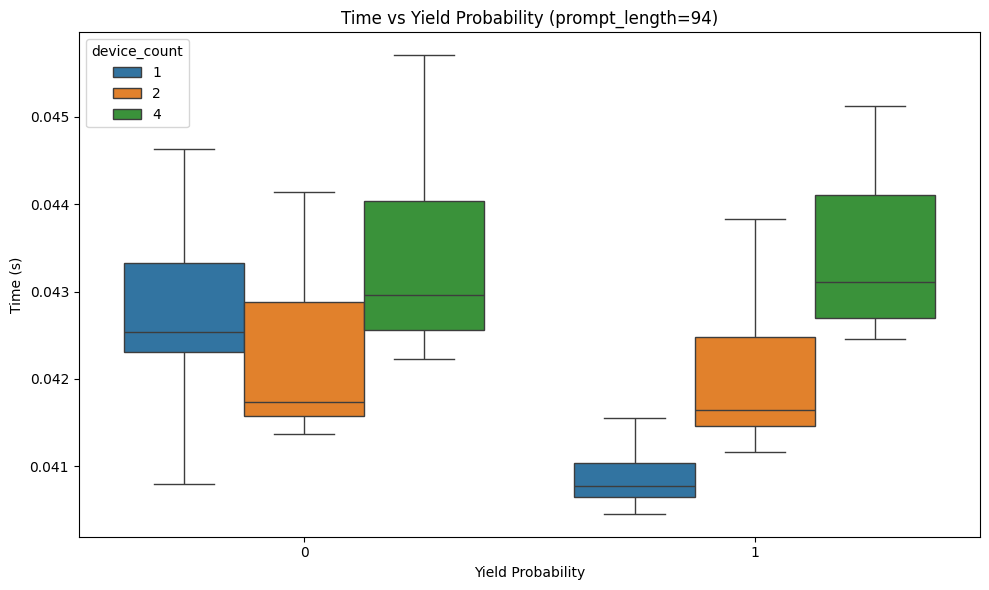

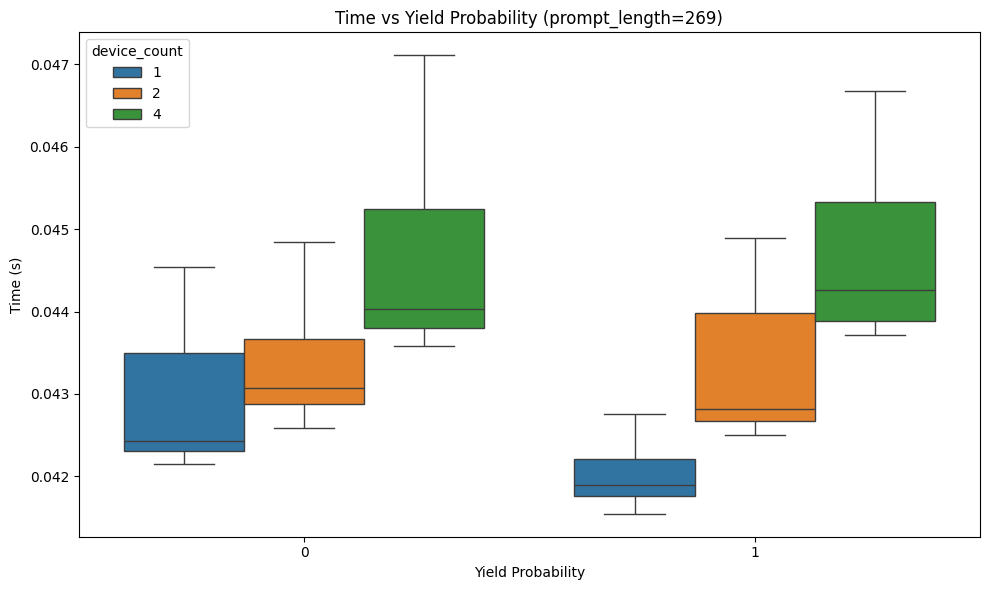

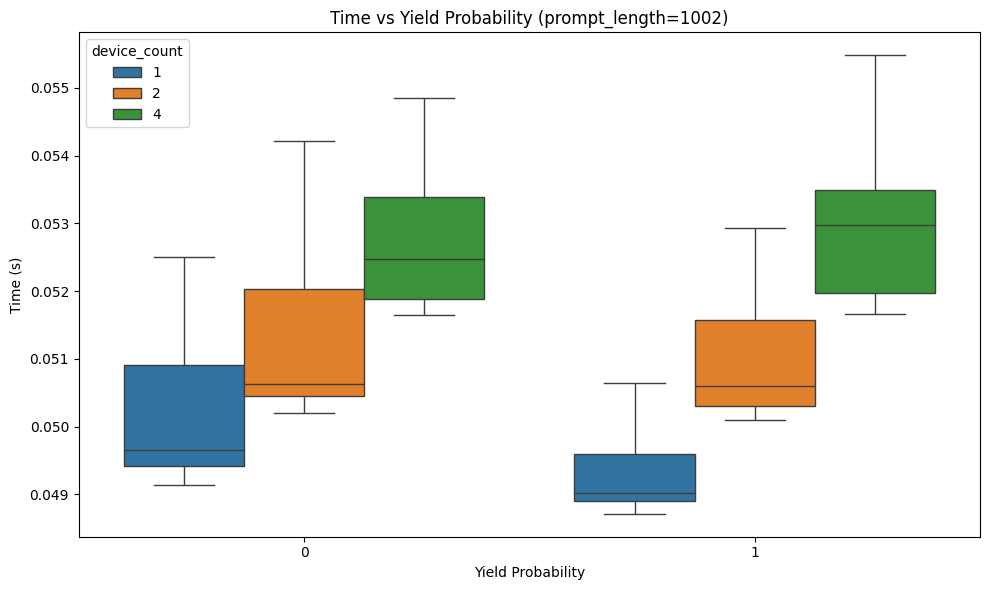

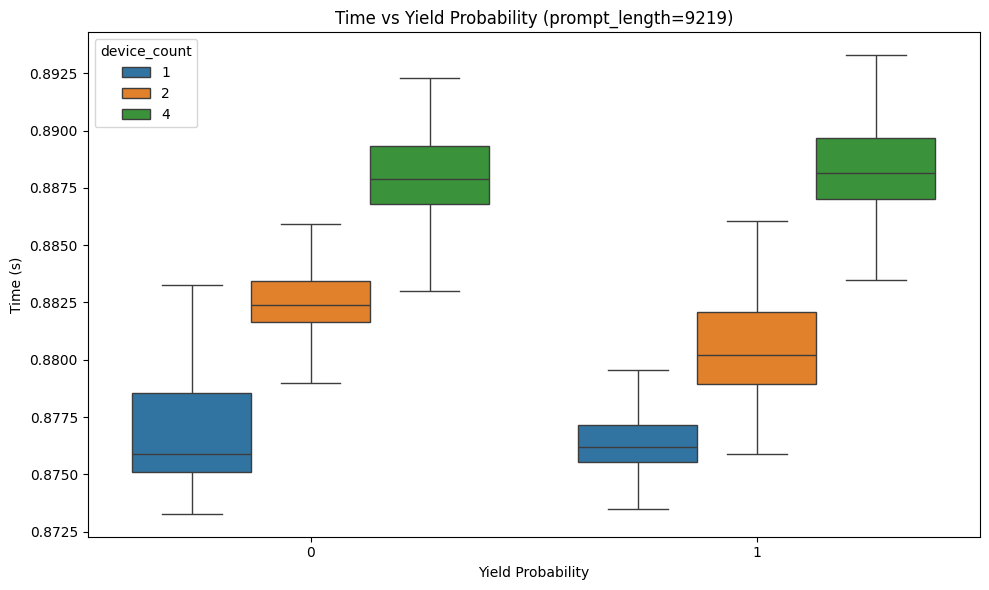

In [ ]:
import seaborn as sns

for pl in sorted(data["prompt_length"].unique()):
    plt.figure(figsize=(10, 6))
    subset = data[data["prompt_length"] == pl]
    sns.boxplot(
        data=subset,
        x="yield_probability",
        y="time",
        hue="device_count",
        palette="tab10",
        showfliers=False
    )
    plt.title(f"Time vs Yield Probability (prompt_length={pl})")
    plt.xlabel("Yield Probability")
    plt.ylabel("Time (s)")
    plt.legend(title="device_count")
    plt.tight_layout()
    plt.show()
